# OIBSIP Data Science Task 2
# Unemployment Analysis with Python

### Objective
To perform Exploratory Data Analysis (EDA) on unemployment data in India
and understand regional and temporal trends, with a focus on the impact
of the COVID-19 pandemic on unemployment rates.

### Technologies Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## Load Dataset

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/deepanshudagdi/Unemployment-in-India/main/Unemployment%20in%20India.csv"

df = pd.read_csv(url)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
# size of the dataset
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (768, 7)

Column names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


## missing values

In [18]:
# Checking for missing values in each column

print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


## Clean text columns

In [17]:
# Removing unnecessary spaces from text values

df["Region"] = df["Region"].str.strip()

if "Region.1" in df.columns:
    df["Region.1"] = df["Region.1"].str.strip()

if "Frequency" in df.columns:
    df["Frequency"] = df["Frequency"].str.strip()

## Date Time

In [13]:
# Check the exact column names in our dataset
print(df.columns.tolist())


# Removing extra spaces from the beginning and end of column names
df.columns = df.columns.str.strip()

# Display the cleaned column names
print(df.columns.tolist())


# Converting the Date column into datetime format
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Checking the converted dates
df["Date"].head()

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[us]

In [15]:
df.dtypes

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object

## Convert numerical columns

In [16]:
# Converting important numerical columns into numeric data types
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Checking the data types
df[numeric_columns].dtypes

Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
dtype: object

## Remove missing rows

In [19]:
# Checking missing values again

print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [ ]:
# Removing rows with missing values in important columns

df = df.dropna(
    subset=[
        "Region",
        "Date",
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
)

print("Dataset shape after cleaning:", df.shape)

## Check duplicate rows

In [20]:
# Checking for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 27


In [21]:
# Removing duplicate rows

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (741, 7)


## Final cleaned dataset

In [22]:
# Displaying the cleaned dataset

df.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,2019-10-31,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,2019-11-30,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,2019-12-31,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,2020-01-31,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,2020-02-29,Monthly,5.91,11723617.0,42.83,Rural


In [23]:
# Getting statistical information about numerical columns

df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [24]:
# Calculating average unemployment rate for each region

region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

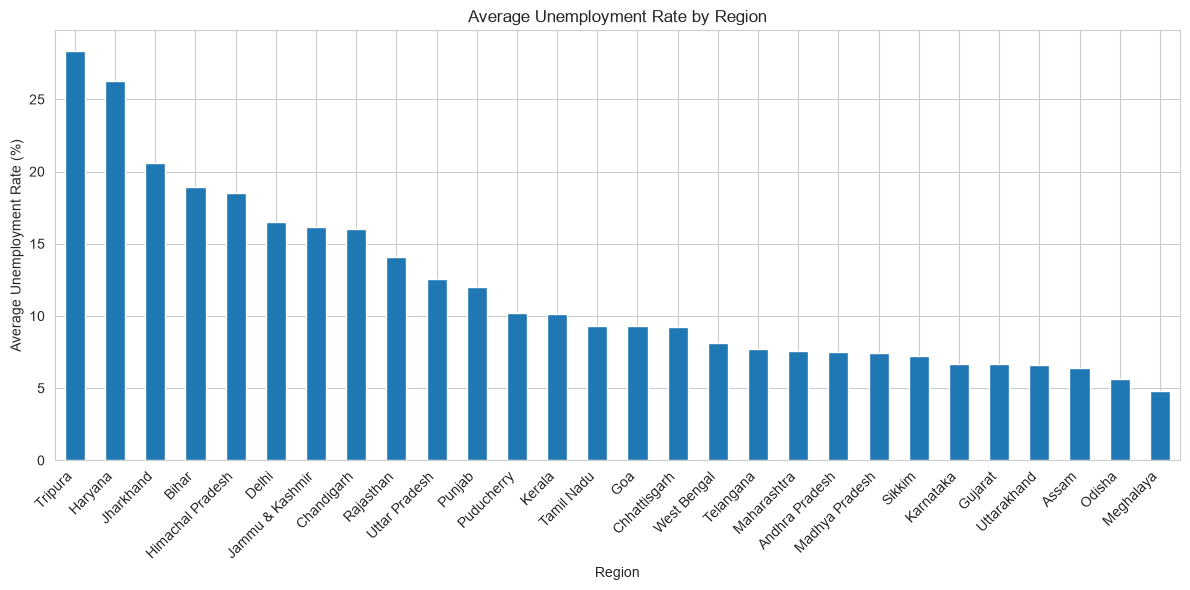

In [25]:
# Plotting average unemployment rate by region

plt.figure(figsize=(12, 6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

From the above chart, I can see that unemployment rates are not the same 
across all regions. Some regions have noticeably higher average unemployment 
rates, while others have lower rates.

This shows that unemployment conditions vary from one region to another. 
The difference can be related to factors such as employment opportunities, 
industries, population and economic conditions.

## Month-wise Unemployment Trend

Next, I will analyze how the unemployment rate changed over time.

Since the dataset contains dates, I can calculate the average unemployment 
rate for each month. This will help me identify periods when unemployment 
increased or decreased.

In [26]:
# Creating a month column from the Date column

df["Month"] = df["Date"].dt.to_period("M")

# Calculating monthly average unemployment rate

monthly_unemployment = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
)

monthly_unemployment.head()

Month
2019-05    8.874259
2019-06    9.303333
2019-07    9.033889
2019-08    9.637925
2019-09    9.051731
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64

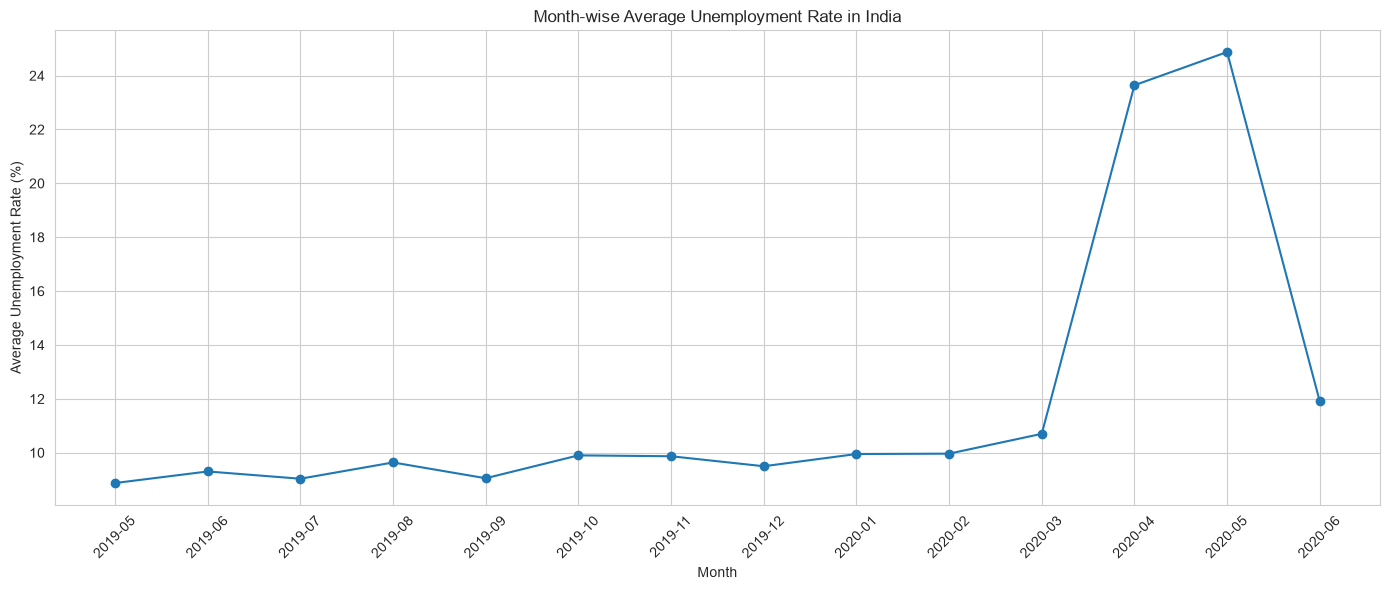

In [27]:
# Plotting the monthly unemployment trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment.index.astype(str),
    monthly_unemployment.values,
    marker="o"
)

plt.title("Month-wise Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Time-Series Analysis for Selected Regions

Now I will compare the unemployment rates of three regions over time.

I have selected three regions from the dataset so that I can observe how 
their unemployment rates changed during the same period.

In [28]:
# Displaying all available regions

print(df["Region"].unique())

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
                nan,       'Chandigarh']
Length: 29, dtype: str


In [29]:
selected_regions = ["Maharashtra", "Gujarat", "Haryana"]

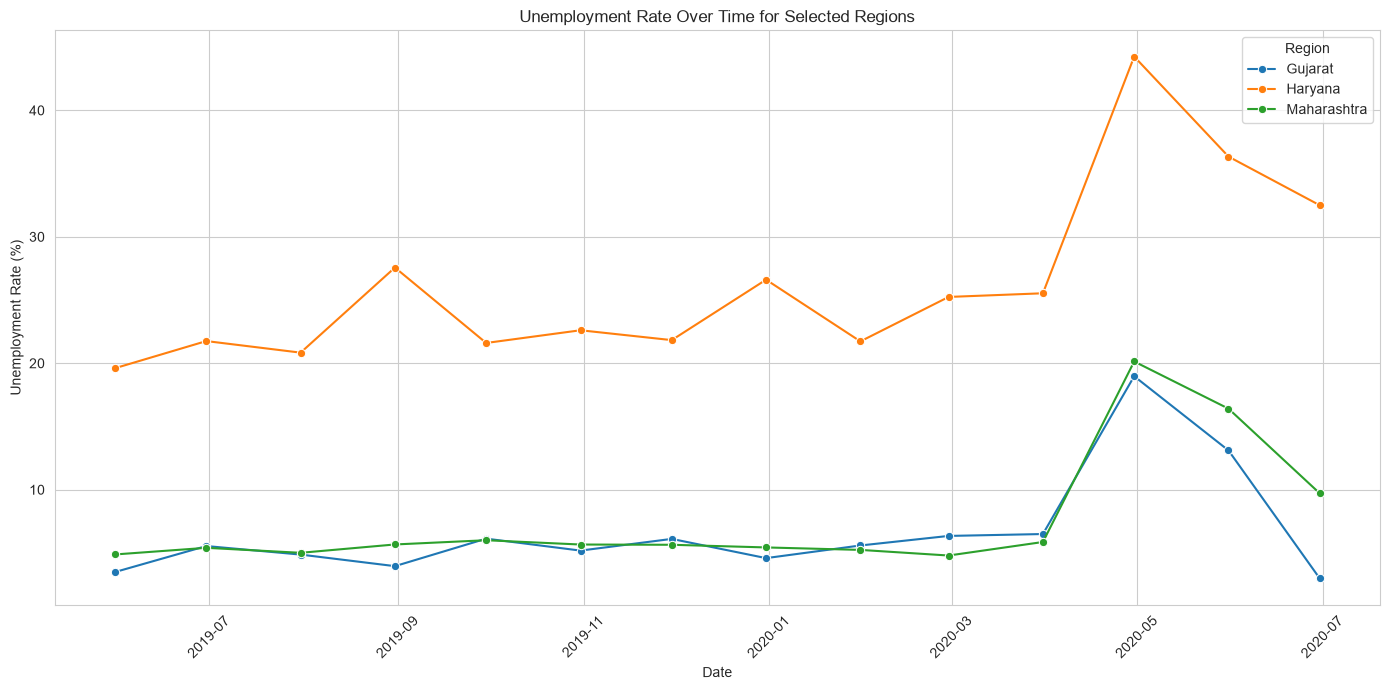

In [30]:
# Selecting three regions for comparison

selected_regions = ["Maharashtra", "Gujarat", "Haryana"]

region_data = df[df["Region"].isin(selected_regions)]

# Calculating average unemployment rate by date and region

region_time_series = (
    region_data
    .groupby(["Date", "Region"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

# Creating the line chart

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=region_time_series,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Over Time for Selected Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Top 10 States with Highest Average Unemployment Rate

Next, I want to find the states or regions with the highest average 
unemployment rates.

I will calculate the average unemployment rate for every region and select 
the top 10 regions with the highest values.

In [31]:
# Finding the top 10 regions with the highest average unemployment rate

top_10_regions = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

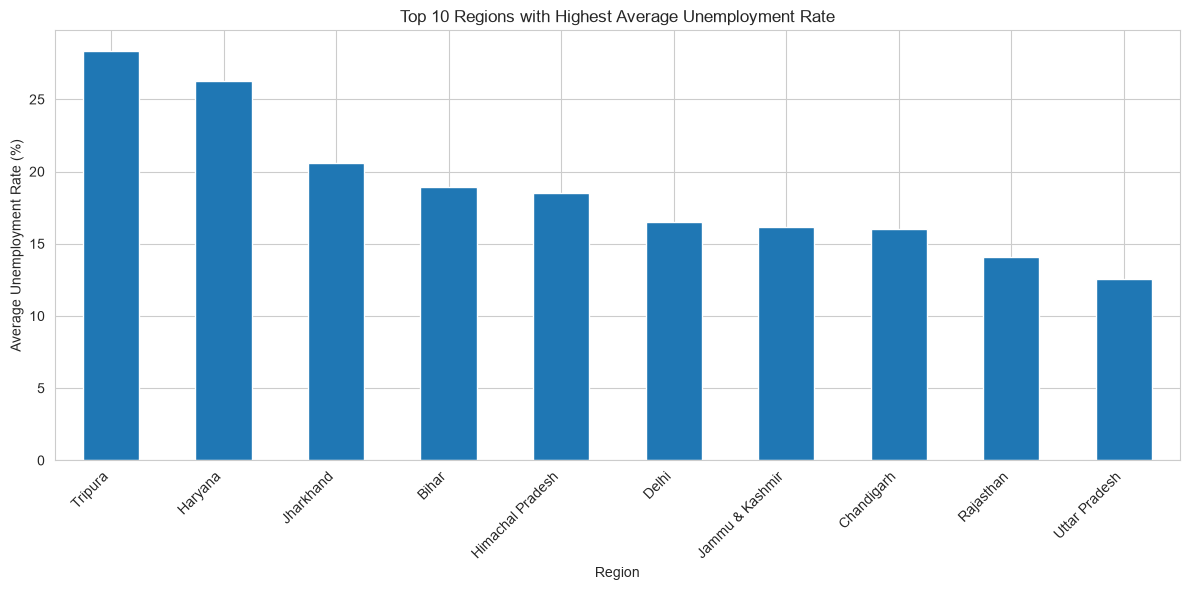

In [32]:
# Plotting the top 10 regions

plt.figure(figsize=(12, 6))

top_10_regions.plot(kind="bar")

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 5. Correlation Between Economic Indicators

In this section, I will study the relationship between unemployment rate, 
employment and labour participation rate.

Correlation helps us understand whether two numerical variables tend to 
move together.

I will use a heatmap because it provides an easy visual representation 
of the correlation values.


## Correlation Between Economic Indicators

In this section, I will study the relationship between unemployment rate, 
employment and labour participation rate.

Correlation helps us understand whether two numerical variables tend to 
move together.

I will use a heatmap because it provides an easy visual representation 
of the correlation values.

In [33]:
# Selecting the columns required for correlation analysis

correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


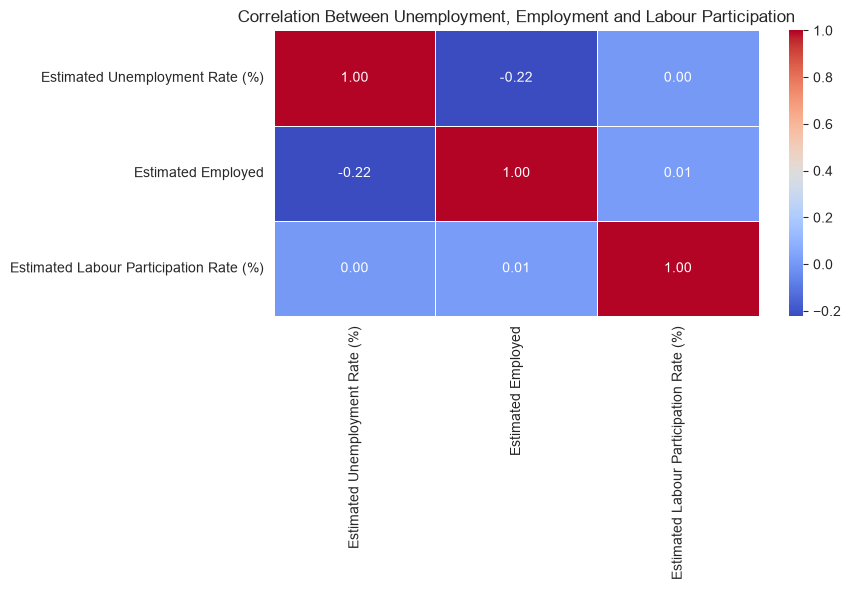

In [34]:
# Creating the correlation heatmap

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Unemployment, Employment and Labour Participation")

plt.tight_layout()
plt.show()

## Pre-COVID vs Post-COVID Comparison

The COVID-19 pandemic had a major effect on employment and economic activity 
in India.

To understand this change, I will divide the dataset into two periods:

- Pre-COVID: Before March 2020
- Post-COVID: March 2020 onwards

I will then compare the average unemployment rate, employment and labour 
participation rate between these periods.

In [38]:
# Defining the COVID-19 comparison date
covid_start = pd.Timestamp("2020-03-01")

# Creating a new column to classify the data
df["COVID_Period"] = np.where(
    df["Date"] < covid_start,
    "Pre-COVID",
    "Post-COVID"
)

# Checking the result
df[["Date", "COVID_Period"]].head()

# Checking how many observations belong to each period
df["COVID_Period"].value_counts()


COVID_Period
Pre-COVID     536
Post-COVID    205
Name: count, dtype: int64

In [40]:
# Calculating average values for both periods
covid_comparison = (
    df.groupby("COVID_Period")[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)"
        ]
    ]
    .mean()
)

covid_comparison

# Rounding the values for easier reading

covid_comparison.round(2)

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
COVID_Period,,,
Post-COVID,17.77,6517203.34,39.33
Pre-COVID,9.51,7466027.87,43.89


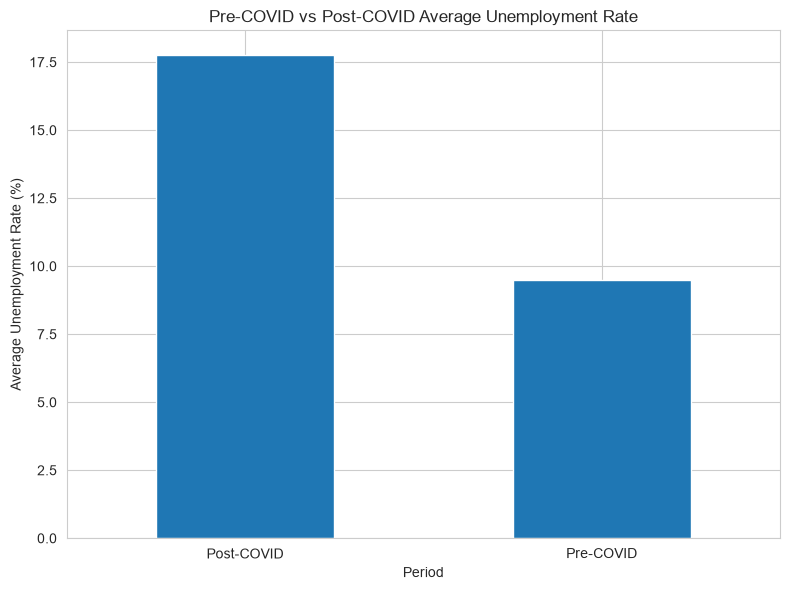

In [41]:
# Plotting the average unemployment rate before and after COVID-19

plt.figure(figsize=(8, 6))

covid_comparison["Estimated Unemployment Rate (%)"].plot(
    kind="bar"
)

plt.title("Pre-COVID vs Post-COVID Average Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The comparison shows a clear difference between the average unemployment 
rate before and after the beginning of the COVID-19 period.

The post-COVID period shows higher unemployment compared with the pre-COVID 
period in the dataset. This indicates that the pandemic and the economic 
restrictions had a negative impact on employment conditions.

The employment and labour participation values also changed between the 
two periods, showing that the labour market was affected during this time.

In [42]:
# Finding the month with the highest average unemployment rate
highest_month = monthly_unemployment.idxmax()
highest_rate = monthly_unemployment.max()

print("Month with highest average unemployment:", highest_month)
print("Unemployment rate:", round(highest_rate, 2), "%")

Month with highest average unemployment: 2020-05
Unemployment rate: 24.88 %


# Final Findings

After analyzing the unemployment dataset, I found the following important points:

1. Unemployment rates vary significantly between different regions of India.

2. The unemployment rate changes over time and is not constant.

3. The COVID-19 period shows a noticeable change in unemployment conditions.

4. Some regions have considerably higher average unemployment rates than others.

5. The time-series analysis shows that different regions experienced 
   different levels of unemployment fluctuations.

6. The correlation heatmap helps in understanding the relationship between 
   unemployment, employment and labour participation.

7. The comparison between pre-COVID and post-COVID periods shows that 
   the pandemic had a significant effect on the labour market.

Overall, this analysis helped me understand how Python, Pandas, Matplotlib 
and Seaborn can be used to analyze real-world economic data.


# Conclusion

In this project, I performed an exploratory data analysis of unemployment 
in India using Python.

I cleaned the dataset, converted the date column, checked missing values 
and analyzed unemployment rates across different regions and months.

I also created different visualizations including bar charts, line charts 
and a correlation heatmap.

The analysis shows that unemployment varied across regions and changed 
significantly over time. The COVID-19 period was particularly important 
because unemployment increased and employment conditions were affected.

This project gave me practical experience with data cleaning, exploratory 
data analysis, visualization and time-series analysis using Python.